### Paper and additional experiments 

Here, we reproduce some of the paper's experiments, and conduct additional ones to test KSGD in new contexts

In [ ]:
#first, import necessary scripts:
from multivariate_normal import MVN, Cauchy
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import pdist, squareform


##### First, we reproduce the code of SVGD from the paper

In [ ]:

class SVGD():
    #this class implements the SVGD algorithm for the median based bandwidth selection

    def __init__(self):
        pass
    
    def svgd_kernel(self, theta, h = -1):
        sq_dist = pdist(theta)
        pairwise_dists = squareform(sq_dist)**2
        if h < 0: # if h < 0, using median trick
            h = np.median(pairwise_dists)  
            h = np.sqrt(0.5 * h / np.log(theta.shape[0]+1))

        # compute the rbf kernel
        Kxy = np.exp( -pairwise_dists / h**2 / 2)

        dxkxy = -np.matmul(Kxy, theta)
        sumkxy = np.sum(Kxy, axis=1)
        for i in range(theta.shape[1]):
            dxkxy[:, i] = dxkxy[:,i] + np.multiply(theta[:,i],sumkxy)
        dxkxy = dxkxy / (h**2)
        return (Kxy, dxkxy)
    
 
    def update(self, x0, lnprob, n_iter = 1000, stepsize = 1e-3, bandwidth = -1, alpha = 0.9, debug = False):
        # Check input
        if x0 is None or lnprob is None:
            raise ValueError('x0 or lnprob cannot be None!')
        
        theta = np.copy(x0) 
        
        # adagrad with momentum
        fudge_factor = 1e-6
        historical_grad = 0
        for iter in range(n_iter):
            if debug and (iter+1) % 1000 == 0:
                print('iter ' + str(iter+1)) 
            
            lnpgrad = lnprob(theta)
            # calculating the kernel matrix
            kxy, dxkxy = self.svgd_kernel(theta, bandwidth)  
            grad_theta = (np.matmul(kxy, lnpgrad) + dxkxy) / x0.shape[0]  
            
            # adagrad 
            if iter == 0:
                historical_grad = historical_grad + grad_theta ** 2
            else:
                historical_grad = alpha * historical_grad + (1 - alpha) * (grad_theta ** 2)
            adj_grad = np.divide(grad_theta, fudge_factor+np.sqrt(historical_grad))
            theta = theta + stepsize * adj_grad 
            
        return theta
    

##### Now, we reproduce the experiments of the paper to simulate a gaussian mixture distribution:

In [18]:
class mixtureGaussian:
    def __init__(self):
        pass
    
    def normal_density(self, x, mu, sigma):
        coeff = 1 / (sigma * np.sqrt(2 * np.pi))
        exponent = -0.5 * ((x - mu) / sigma) ** 2
        return coeff * np.exp(exponent)
    
    def prob(self, theta):
        return (1/3)*self.normal_density(theta, -2, 1) + (2/3)*self.normal_density(theta, 2, 1)
    
    def dprob(self, theta):
        return (1/3)*(- (theta + 2)/1**2)*self.normal_density(theta, -2, 1) + (2/3)*(- (theta - 2)/1**2)*self.normal_density(theta, 2, 1)
    
    def dlnprob(self, theta):
        #returns the derivative of the log-probability density function at theta
        return self.dprob(theta) / self.prob(theta)

We show that the density can indeed be approached through SVGD:

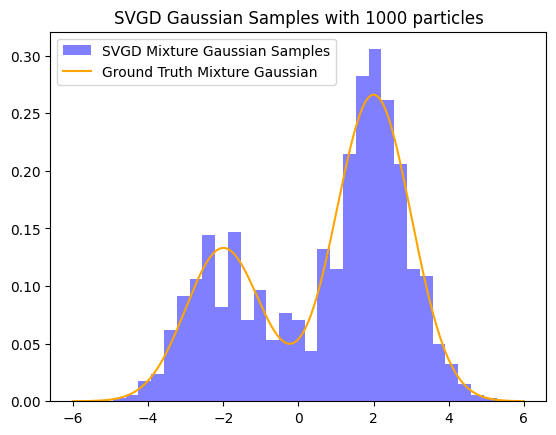

In [19]:
Mixture_Gaussian = mixtureGaussian()

n_particles=1000

x0 = np.random.normal(-10,1, [n_particles,1])
theta_gauss = SVGD().update(x0, Mixture_Gaussian.dlnprob, n_iter=1000, stepsize=0.1)

plt.hist(theta_gauss, density=True, bins=30, alpha=0.5, label='SVGD Mixture Gaussian Samples', color='blue')
plt.plot(np.linspace(-6,6,1000), Mixture_Gaussian.prob(np.linspace(-6,6,1000)), label='Ground Truth Mixture Gaussian', color='orange')
plt.legend()
plt.title(f'SVGD Gaussian Samples with {n_particles} particles')
plt.show()


Then, we compare, as in the paper, the distribution of a particule sampled through SVGD over many attemps:

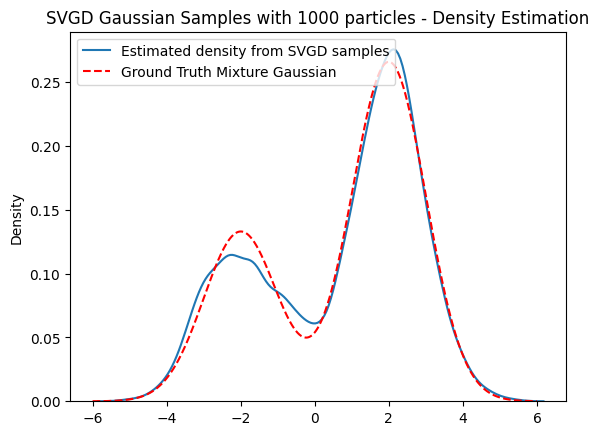

In [20]:
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

sq_dist = pdist(theta_gauss)
pairwise_dists = squareform(sq_dist)
h = np.median(pairwise_dists)  
h = h**2 / np.log(theta_gauss.shape[0]+1)

sns.kdeplot(theta_gauss, color='g',label='Estimated density from SVGD samples', bw_adjust=h)
plt.plot(np.linspace(-6,6,1000), Mixture_Gaussian.prob(np.linspace(-6,6,1000)), label='Ground Truth Mixture Gaussian', color='red', linestyle='--')
plt.legend()
plt.title(f'SVGD Gaussian Samples with {n_particles} particles - Density Estimation')
plt.show()

Finally, we calculate the estimation errors of $\mathbb{E}[h(x)]$ for $h(x)=x$ ,$h(x) = x^2$ and $h(x) = \cos(\omega x+b)$

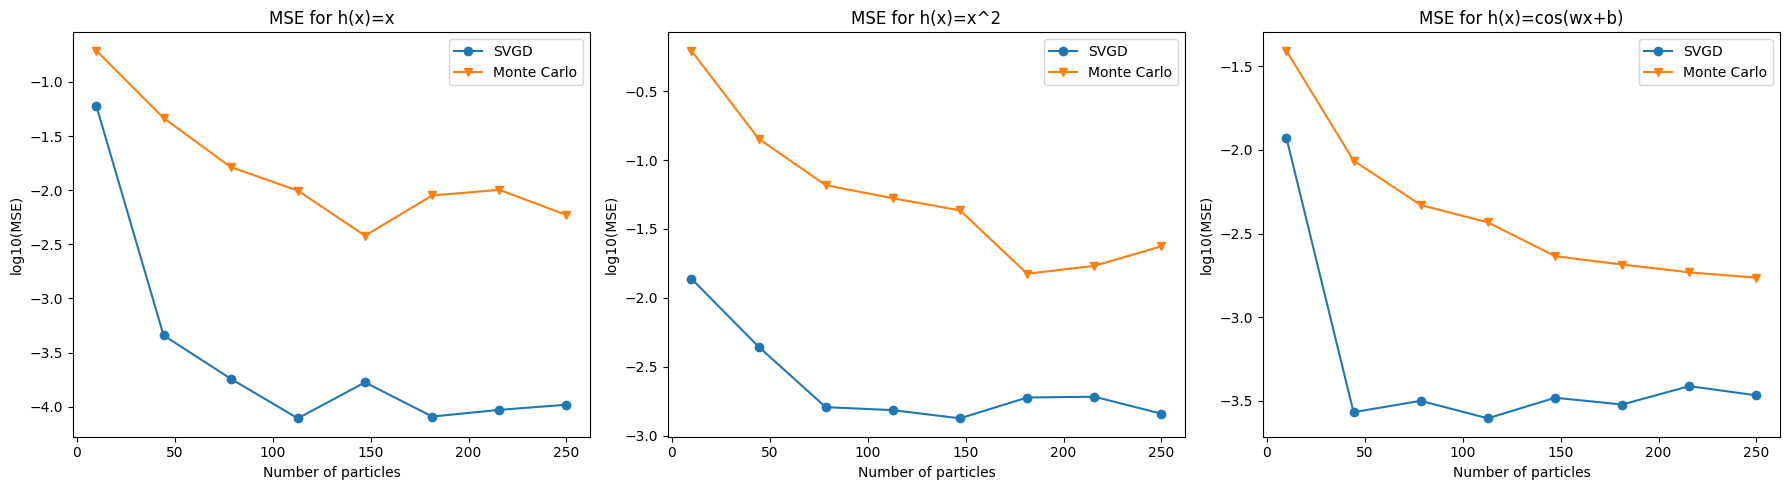

In [24]:
N = 50 # number of runs to calculate MSE
n_list=np.linspace(10,250,8) # test for different number of particles

log10_MSE_SVGD=np.zeros((3, len(n_list)))
log10_MSE_MC=np.zeros((3, len(n_list)))

def direct_sampling_method(n):
    # direct sampling from the mixture Gaussian
    samples = []
    for _ in range(int(n)):
        u = random.uniform(0, 1)
        if u < 1/3:
            sample = np.random.normal(-2, 1)
        else:
            sample = np.random.normal(2, 1)
        samples.append(sample)
    return np.array(samples)

for _ in range(N):
    for i_n,n in enumerate(n_list) :
        x0 = np.random.normal(-10,1, [int(n),1])
        theta_gauss = SVGD().update(x0, Mixture_Gaussian.dlnprob, n_iter=2000, stepsize=0.1)
        theta_MC=direct_sampling_method(n)
        
        #h(x)=x
        log10_MSE_SVGD[0, i_n] += 1/N * np.log10((np.mean(theta_gauss)-2/3)**2)
        log10_MSE_MC[0, i_n] += 1/N* np.log10((np.mean(theta_MC)-2/3)**2)

        #h(x)=x^2
        log10_MSE_SVGD[1, i_n] += 1/N * np.log10((np.mean(theta_gauss**2)-5)**2)
        log10_MSE_MC[1, i_n] += 1/N * np.log10((np.mean(theta_MC**2)-5)**2)
        #h(x)=cos(wx+b)
        # average over 20 draws of (w,b)
        squared_cos_estimates_error_SVGD=[]
        for _ in range(20):
            w=random.uniform(0,5)
            b=random.uniform(0,2*np.pi)
            squared_cos_estimates_error_SVGD.append((np.mean(np.cos(w*theta_gauss + b))-(1/3)*np.exp(-0.5*(w**2)) * np.cos(b + w*(-2)) - (2/3)*np.exp(-0.5*(w**2)) * np.cos(b + w*(2))) ** 2)
        log10_MSE_SVGD[2, i_n] += 1/N * np.log10(np.mean(squared_cos_estimates_error_SVGD))
        
        squared_cos_estimates_error_MC=[]
        for _ in range(20):
            w=random.uniform(0,5)
            b=random.uniform(0,2*np.pi)
            squared_cos_estimates_error_MC.append((np.mean(np.cos(w*theta_MC + b))-(1/3)*np.exp(-0.5*(w**2)) * np.cos(b + w*(-2)) - (2/3)*np.exp(-0.5*(w**2)) * np.cos(b + w*(2))) ** 2)
        log10_MSE_MC[2, i_n] += 1/N * np.log10(np.mean(squared_cos_estimates_error_MC))

#now, we plot the errors (1 plot per function g)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].plot(n_list, log10_MSE_SVGD[0, :], label='SVGD', marker='o')
axs[0].plot(n_list, log10_MSE_MC[0, :], label='Monte Carlo', marker='v')
axs[0].set_title('MSE for h(x)=x')
axs[0].set_xlabel('Number of particles')
axs[0].set_ylabel('log10(MSE)')
axs[0].legend()

axs[1].plot(n_list, log10_MSE_SVGD[1, :], label='SVGD', marker='o')
axs[1].plot(n_list, log10_MSE_MC[1, :], label='Monte Carlo', marker='v')
axs[1].set_title('MSE for h(x)=x^2')
axs[1].set_xlabel('Number of particles')
axs[1].set_ylabel('log10(MSE)')
axs[1].legend()

axs[2].plot(n_list, log10_MSE_SVGD[2, :], label='SVGD', marker='o')
axs[2].plot(n_list, log10_MSE_MC[2, :], label='Monte Carlo', marker='v')
axs[2].set_title('MSE for h(x)=cos(wx+b)')
axs[2].set_xlabel('Number of particles')
axs[2].set_ylabel('log10(MSE)')
axs[2].legend()

plt.tight_layout()
plt.show()
    

Then, we test the same procedure for a cauchy distribution:

In [6]:
class Cauchy:
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def prob(self, x):
        return 1 / (np.pi * self.sigma * (1 + ((x - self.mu) / self.sigma) ** 2))

    def dlnprob(self, theta):
        return -1*(2/self.sigma)*((theta-self.mu)/(1+((theta - self.mu) / self.sigma) ** 2))


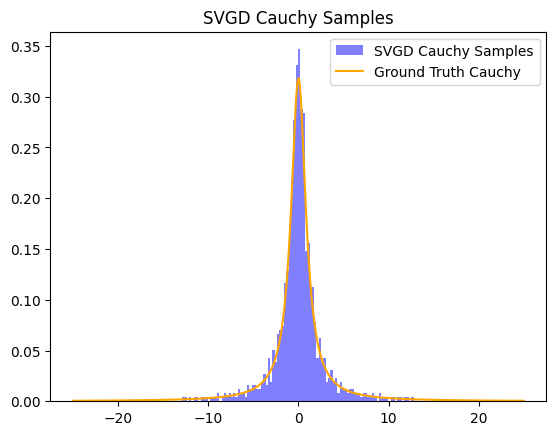

In [7]:
mu_cauchy, sigma_cauchy = 0, 1
Cauchy_model = Cauchy(mu_cauchy, sigma_cauchy)


n_particles=1000

x0 = np.random.normal(0,1, [n_particles,1])

theta_cauchy = SVGD().update(x0, Cauchy_model.dlnprob, n_iter=1000, stepsize=0.01)


plt.hist(theta_cauchy, density=True, bins=100, alpha=0.5, label='SVGD Cauchy Samples', color='blue')
plt.plot(np.linspace(-25,25,1000), Cauchy_model.prob(np.linspace(-25,25,1000)), label='Ground Truth Cauchy', color='orange')
plt.legend()
plt.title('SVGD Cauchy Samples')
plt.show()

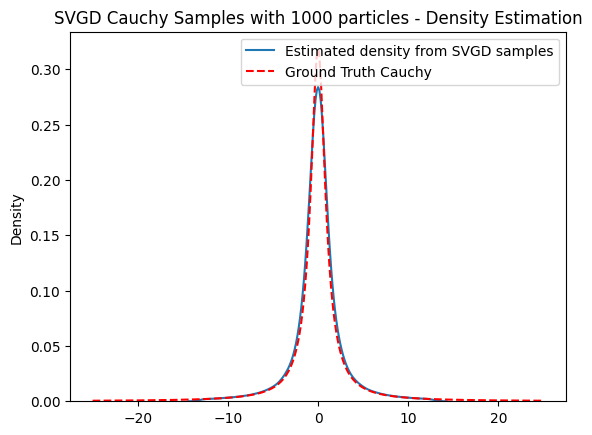

In [8]:
import seaborn as sns
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

sq_dist = pdist(theta_gauss)
pairwise_dists = squareform(sq_dist)
h = np.median(pairwise_dists)  
h = h**2 / np.log(theta_gauss.shape[0]+1)

sns.kdeplot(theta_cauchy, color='g',label='Estimated density from SVGD samples', bw_adjust=h)
plt.plot(np.linspace(-25,25,1000), Cauchy_model.prob(np.linspace(-25,25,1000)), label='Ground Truth Cauchy', color='red', linestyle='--')
plt.legend()
plt.title(f'SVGD Cauchy Samples with {n_particles} particles - Density Estimation')
plt.show()

Finally, we calculate the estimation errors of $\mathbb{E}[h(X)]$ for $h(x)=\arctan(x)$ 

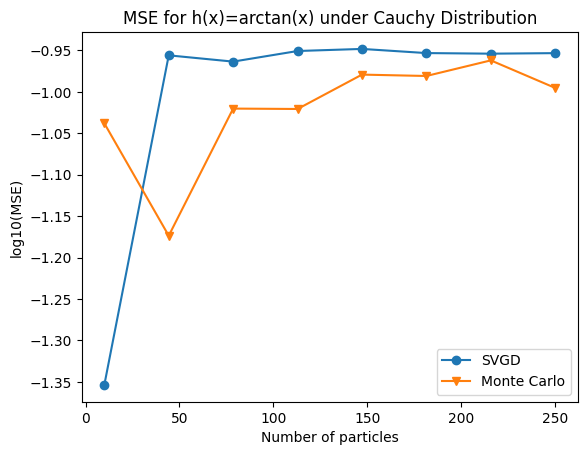

In [15]:
N = 100 # number of runs to calculate MSE
n_list=np.linspace(10,250,8) # test for different number of particles
mu_cauchy, sigma_cauchy = 0, 1

log10_MSE_SVGD=np.zeros(len(n_list))
log10_MSE_MC=np.zeros(len(n_list))

def direct_sampling_cauchy_method(n):
    # direct sampling from the Cauchy distribution
    samples = mu_cauchy + sigma_cauchy * np.random.standard_cauchy(n)
    return samples

for _ in range(N):
    for i_n,n in enumerate(n_list) :
        x0 = np.random.normal(-10,1, [int(n),1])
        theta_gauss = SVGD().update(x0, Mixture_Gaussian.dlnprob, n_iter=2000, stepsize=0.1)
        theta_MC=direct_sampling_method(n)
        
        #h(x)=arctan(x)
        log10_MSE_SVGD[i_n] += 1/N * np.log10(np.mean(np.arctan(theta_gauss))**2)
        log10_MSE_MC[i_n] += 1/N * np.log10(np.mean(np.arctan(theta_MC))**2)

#now, we plot the errors

plt.plot(n_list, log10_MSE_SVGD, label='SVGD', marker='o')
plt.plot(n_list, log10_MSE_MC, label='Monte Carlo', marker='v')
plt.title('MSE for h(x)=arctan(x) under Cauchy Distribution')
plt.xlabel('Number of particles')
plt.ylabel('log10(MSE)')
plt.legend()
plt.show()

    

Finally, we investigate how SVGD behaves for high dimensional target distributions. Here, we take a high dimensional gaussian

In [ ]:
class HighDimGaussian:
    def __init__(self,  n_particles=50, dim=100):
        self.mu = np.zeros(dim)
        self.sigma = np.eye(dim)
        self.dim = dim
    
    def prob(self, theta):
        coeff = 1 / ((2 * np.pi) ** (len(self.mu) / 2) * np.linalg.det(self.sigma) ** 0.5)
        exponent = -0.5 * np.sum((theta - self.mu) @ np.linalg.inv(self.sigma) * (theta - self.mu), axis=1)
        return coeff * np.exp(exponent)
    
    def dlnprob(self, theta):
        inv_sigma = np.eye(self.dim)#np.linalg.inv(self.sigma)
        return -inv_sigma @ (theta - self.mu).T

In [ ]:

from matplotlib import cm

def experiment_dimension(dim=50, n_particles=50):
    high_dim_gauss = HighDimGaussian(n_particles=n_particles, dim=dim)
    x0 = np.random.normal(0, 0.8, [n_particles, dim])  # initial particles
    theta_hd_gauss = SVGD().update(x0, high_dim_gauss.dlnprob, n_iter=20000, stepsize=0.1)

    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)
    Z = (1 / (2 * np.pi)) * np.exp(-0.5 * (X**2 + Y**2))  # true 2D marginal density

    plt.figure(figsize=(6, 6))
    plt.imshow(
        Z, 
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap=cm.viridis,
        alpha=0.9,
        aspect='equal'
    )

    plt.scatter(theta_hd_gauss[:, 0], theta_hd_gauss[:, 1],
                alpha=0.8, color='crimson', edgecolor='white',
                linewidth=0.5, label='SVGD Samples', s=25)

    plt.colorbar(label='True Gaussian Density') 
    plt.title(f'SVGD Samples in {dim}D Gaussian\n(First Two Dimensions)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.tight_layout()
    plt.show()



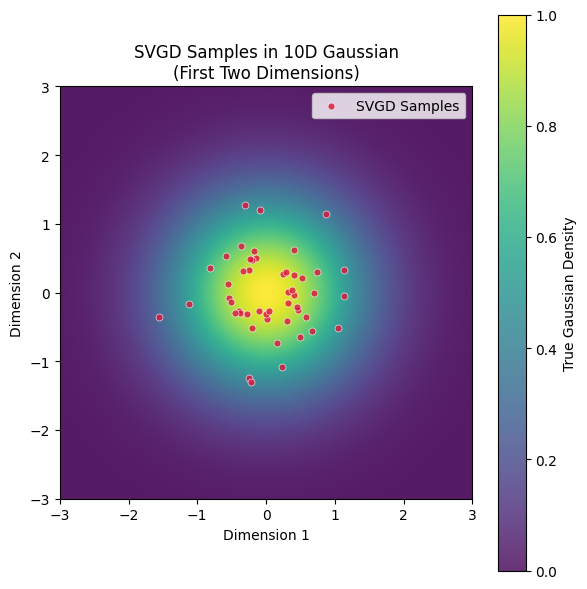

In [41]:
experiment_dimension(dim=10)

In [ ]:


def experiment_dimension_subplot(dims=(10, 50, 100, 250), n_particles=50):
    # prepare figure
    fig, axes = plt.subplots(1, len(dims), figsize=(18, 4))
    
    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)
    Z = (1 / (2 * np.pi)) * np.exp(-0.5 * (X**2 + Y**2))

    for i, dim in enumerate(dims):
        ax = axes[i]
        
        high_dim_gauss = HighDimGaussian(n_particles=n_particles, dim=dim)
        x0 = np.random.normal(0, 0.8, [n_particles, dim])
        theta_hd_gauss = SVGD().update(x0, high_dim_gauss.dlnprob, n_iter=20000, stepsize=0.1)

        im = ax.imshow(
            Z,
            extent=[x.min(), x.max(), y.min(), y.max()],
            origin="lower",
            cmap=cm.viridis,
            alpha=0.9,
            aspect="equal"
        )

        ax.scatter(theta_hd_gauss[:, 0], theta_hd_gauss[:, 1],
                   alpha=0.8, color='crimson', edgecolor='white',
                   linewidth=0.5, s=20)

        ax.set_title(f"{dim}D Gaussian", fontsize=12)
        ax.set_xlabel("Dim 1")
        if i == 0:
            ax.set_ylabel("Dim 2")
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_xticks([-2, 0, 2])
        ax.set_yticks([-2, 0, 2])

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("True Gaussian Density", fontsize=11)

    fig.suptitle("SVGD Particles for Increasing Dimensionality", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


C:\Users\mathi\AppData\Local\Temp\ipykernel_24416\525791694.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


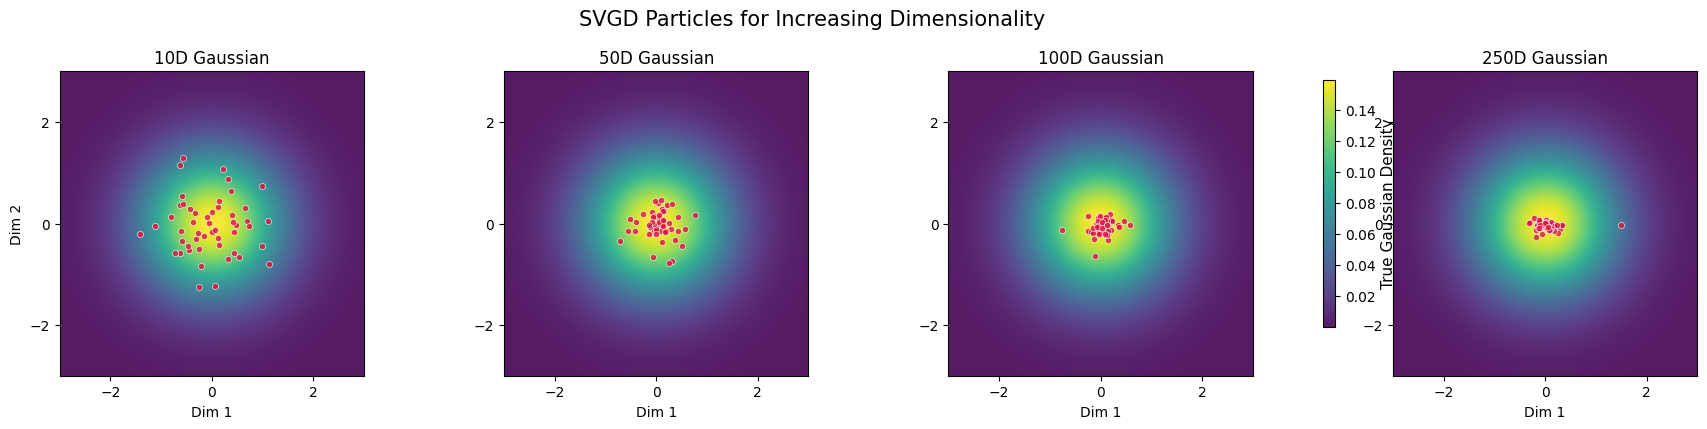

In [45]:
experiment_dimension_subplot()